In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


✅ Number Plate Detected


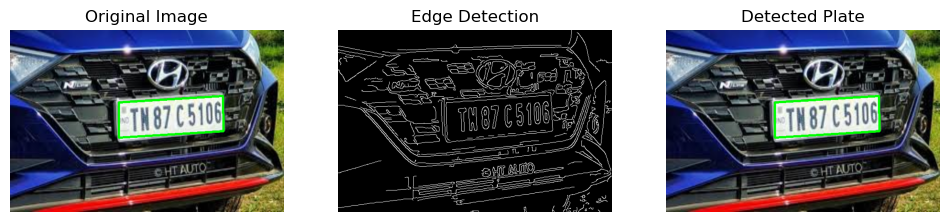

In [2]:
# ================================
# VEHICLE NUMBER PLATE DETECTION
# USING CONTOUR METHOD
# ================================

# 1. Read the input image
image = cv2.imread("/Users/akashgiri/Downloads/download.jpeg")   # <-- replace with your image path
image = cv2.resize(image, (600, 400))

# 2. Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 3. Noise removal using Gaussian Blur
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# 4. Edge detection using Canny
edges = cv2.Canny(blur, 100, 200)

# 5. Morphological closing to strengthen plate edges
kernel = np.ones((5, 5), np.uint8)
morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

# 6. Find contours
contours, _ = cv2.findContours(
    morph,
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_SIMPLE
)

# 7. Sort contours based on area (largest first)
contours = sorted(contours, key=cv2.contourArea, reverse=True)

plate_contour = None

# 8. Loop through contours to find rectangular plate
for cnt in contours:
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)

    # Number plate is usually rectangular (4 sides)
    if len(approx) == 4:
        plate_contour = approx
        break

# 9. Draw detected number plate contour
if plate_contour is not None:
    cv2.drawContours(image, [plate_contour], -1, (0, 255, 0), 3)
    print("✅ Number Plate Detected")
else:
    print("❌ Number Plate Not Detected")

# 10. Display results
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Edge Detection")
plt.imshow(edges, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Detected Plate")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()
